In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [79]:
NUM_PARTICLES       = 64
WIDTH               = 16
HEIGHT              = 16

DT                  = 0.1
KERNEL_RADIUS       = 2
PRESSURE_FORCE      = 1
WALL_RESTITUTION    = 0.5

In [69]:
def smoothing_kernel(distance):
    normalized = distance / KERNEL_RADIUS
    value = np.maximum(1 - normalized * normalized, np.zeros_like(distance))
    return value * value * value

def d_smoothing_kernel(distance):
    normalized = distance / KERNEL_RADIUS
    value = np.maximum(1 - normalized * normalized, np.zeros_like(distance))
    return (3 * value * value) * (-2 * normalized) / KERNEL_RADIUS

def calculate_density(positions, index):
    res = 0.0

    for i in range(NUM_PARTICLES):
        if index == i:
            continue

        disp = positions[i] - positions[index]
        dist = np.linalg.norm(disp)
        res += smoothing_kernel(dist)

    return res

def calculate_pressure(positions, densities, index):
    res = np.array([0, 0], dtype='float32')

    for i in range(NUM_PARTICLES):
        if index == i:
            continue

        disp = positions[i] - positions[index]
        dist = np.linalg.norm(disp)
        dir  = disp / dist if dist > 0 else np.random.normal(size=(2))

        density = densities[i]
        slope   = d_smoothing_kernel(dist)

        res += density * slope * dir

    return res


In [44]:
%matplotlib inline

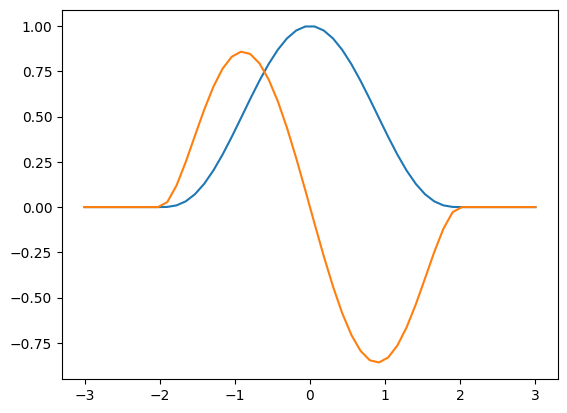

In [71]:
xs = np.linspace(-3, 3, 50)

plt.plot(xs, smoothing_kernel(xs))
plt.plot(xs, d_smoothing_kernel(xs))
plt.show()

In [ ]:
def smoothing_kernel(distance):
    normalized = distance / KERNEL_RADIUS
    value = np.maximum(1 - normalized * normalized, np.zeros_like(distance))
    return value * value * value


def d_smoothing_kernel(distance):
    normalized = distance / KERNEL_RADIUS
    value = np.maximum(1 - normalized * normalized, np.zeros_like(distance))
    return (3 * value * value) * (-2 * normalized) / KERNEL_RADIUS


def calculate_density(positions, index):
    res = 0.0

    for i in range(NUM_PARTICLES):
        if index == i:
            continue

        disp = positions[i] - positions[index]
        dist = np.linalg.norm(disp)
        res += smoothing_kernel(dist)

    return res


def calculate_pressure(positions, densities, index):
    res = np.array([0, 0], dtype="float32")

    for i in range(NUM_PARTICLES):
        if index == i:
            continue

        disp = positions[i] - positions[index]
        dist = np.linalg.norm(disp)
        dir = disp / dist if dist > 0 else np.random.normal(size=(2))

        density = densities[i]
        slope = d_smoothing_kernel(dist)

        res += density * slope * dir

    return res

In [72]:
%matplotlib ipympl

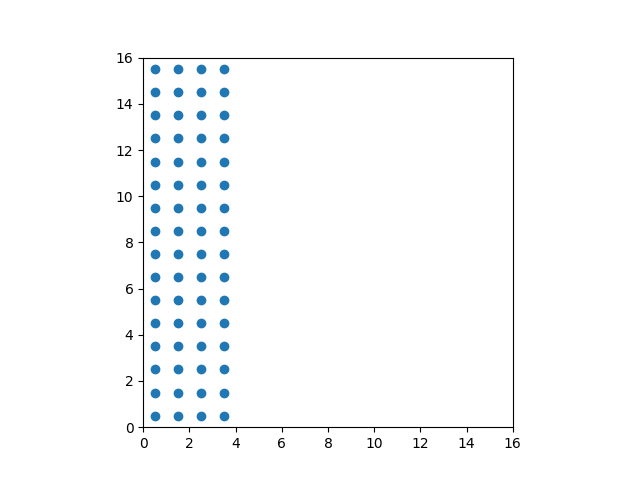

In [80]:
plt.clf()
plt.cla()

fig, ax = plt.subplots()
ax.set_xlim(0, WIDTH)
ax.set_ylim(0, HEIGHT)
ax.set_aspect('equal')

positions  = np.zeros((NUM_PARTICLES, 2))
velocities = np.zeros((NUM_PARTICLES, 2))
densities  = np.zeros((NUM_PARTICLES))

for i in range(NUM_PARTICLES):
    positions[i]  = np.array([i % WIDTH + 0.5, i // WIDTH + 0.5], dtype='float64')
    velocities[i] = np.array([0, 0], dtype='float64')

scat = ax.scatter(positions[:,1], positions[:,0])
# im   = ax.imshow(density)

def update(frame):
    for i in range(NUM_PARTICLES):
        densities[i] = calculate_density(positions, i)
        
    for i in range(NUM_PARTICLES):
        pressure = calculate_pressure(positions, densities, i)

        velocities[i] += pressure * PRESSURE_FORCE * DT
        velocities[i] += np.array([0, -1], dtype='float64') * DT

        positions[i] += velocities[i] * DT

        if positions[i][0] < 0.5:
            positions[i][0] = 0.5
            velocities[i][0] *= -WALL_RESTITUTION

        if positions[i][0] > WIDTH - 0.5:
            positions[i][0] = WIDTH - 0.5
            velocities[i][0] *= -WALL_RESTITUTION

        if positions[i][1] < 0.5:
            positions[i][1] = 0.5
            velocities[i][1] *= -WALL_RESTITUTION

        if positions[i][1] > HEIGHT - 0.5:
            positions[i][1] = HEIGHT - 0.5
            velocities[i][1] *= -WALL_RESTITUTION

    scat.set_offsets(positions)

    return (scat)

ani = animation.FuncAnimation(fig=fig, func=update, frames=40, interval=30)
plt.show()


In [81]:
ani.event_source.stop()